# Aufgabenstellung
1. RC-Reihenschaltung. Messen Sie die Transferfunktion $|U_R/U_0|$ sowie die Phasenverschiebung
$\theta$ zwischen Strom und Spannung als Funktion der Frequenz. Bestimmen Sie die Kapazität
des Kondensators durch Fit der Modellfunktionen an die Daten der Transferfunktion und
der Phasenverschiebung.
2. RL-Reihenschaltung. Messen Sie die Transferfunktion $|U_R/U_0|$ sowie die Phasenverschiebung
$\theta$ zwischen Strom und Spannung als Funktion der Frequenz. Bestimmen Sie die Induktivität
der Spule durch Fit der Modellfunktionen an die Daten der Transferfunktion und der Pha-
senverschiebung.
3. Serienschwingkreis. Messen Sie die Transferfunktion $|UR/_U0|_$ sowie die Phasenverschiebung
$\theta$ zwischen Strom und Spannung als Funktion der Frequenz. Bestimmen Sie das Wider-
standsverhältnis r = R_d/(R_d + R_{sp})$, die Dämpfungskonstante $δ = (R_d + R_{sp})/(2L)$ sowie
die Resonanzfrequenz $f_0$ durch Fit der Modellfunktionen an die Daten der Transferfunktion
und der Phasenverschiebung.
4. Parallelschwingkreis. Messen Sie die Transferfunktion $|U_R/U_0|$ sowie die Phasenverschiebung
$\theta$ zwischen Strom und Spannung als Funktion der Frequenz. Bestimmen Sie das Wider-
standsverhältnis r = R_d/(R_d + R_{sp})$, die Dämpfungskonstante $δ = (R_d + R_{sp})/(2L)$ sowie
die Resonanzfrequenz $f_0$ durch Fit der Modellfunktionen an die Daten der Transferfunktion
und der Phasenverschiebung.

# Aufgabe 1

=== Schätzergebnisse (RC-Hochpass, Spannung am Widerstand) ===
τ = 2.367792e-04 s
f_c = 672.17 Hz
C (R=986 Ω) = 240.1 nF
RMSE Betrag = 0.44 dB
RMSE Phase  = 1.88 °


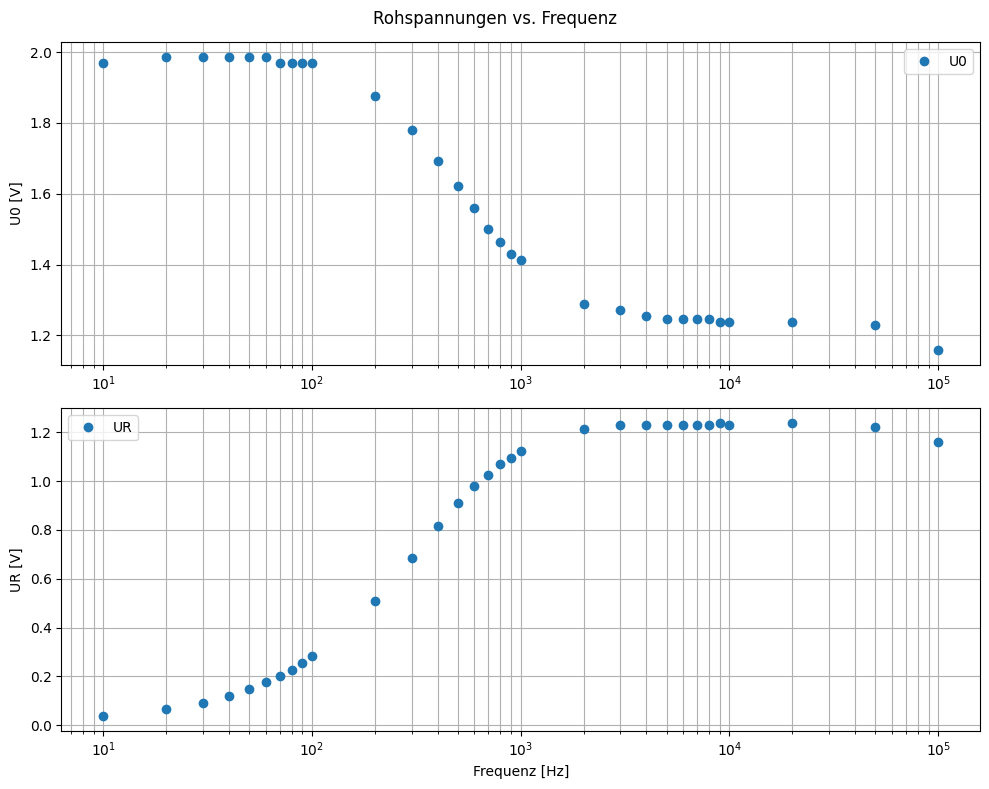

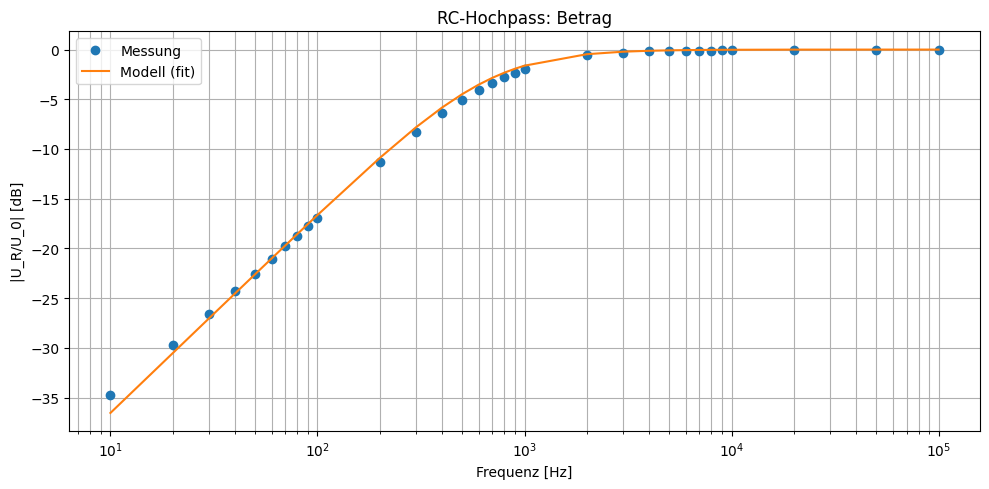

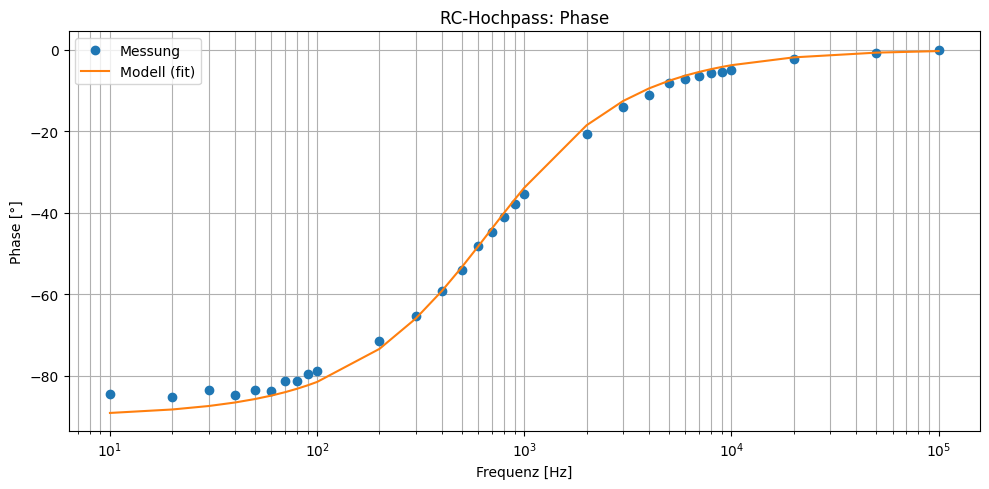

In [7]:
# ==== Auswertung RC-Hochpass (|U_R/U_0|, Phase, Fit) ====
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---- Parameter ----
R = 986.0  # Ohm

# ---- CSV laden (dein Pfad) ----
df = pd.read_csv('Messwerte/Aufgabe1.csv')
df.columns = df.columns.str.replace('"', '').str.strip()

# Spalten referenzieren
f = df['Freq [Hz]'].to_numpy(dtype=float)
U0 = df['U_0 [V]'].to_numpy(dtype=float)
UR = df['U_R [V]'].to_numpy(dtype=float)
theta_deg_raw = df['theta [°]'].to_numpy(dtype=float)

# ---- Messgrößen berechnen ----
mag_meas = UR / U0
phase_meas = ((theta_deg_raw + 180.0) % 360.0) - 180.0  # -> (-180, 180]

# ---- Modell RC-Hochpass (Spannung über R) ----
w = 2.0 * np.pi * f

def hp_mag(w, tau):
    x = w * tau
    return x / np.sqrt(1.0 + x**2)

def hp_phase_deg(w, tau):
    # φ = arctan(ωτ) - 90°
    return np.degrees(np.arctan(w * tau)) - 90.0

def mag2db(x):
    return 20.0 * np.log10(np.clip(x, 1e-20, None))

# ---- Fit von tau (1D-Grid auf dB-Fehler) ----
taus = np.logspace(-6, -1, 4000)  # 1 µs .. 0.1 s
meas_db = mag2db(mag_meas)
err_best = np.inf
tau_best = None
for tau in taus:
    model_db = mag2db(hp_mag(w, tau))
    err = np.mean((meas_db - model_db)**2)
    if err < err_best:
        err_best = err
        tau_best = float(tau)

# ---- Abgeleitete Größen ----
fc = 1.0 / (2.0 * np.pi * tau_best)
C_est = tau_best / R  # Farad
phase_model = hp_phase_deg(w, tau_best)
mag_model = hp_mag(w, tau_best)

mag_rmse_db = float(np.sqrt(np.mean((mag2db(mag_meas) - mag2db(mag_model))**2)))
phase_rmse_deg = float(np.sqrt(np.mean((phase_meas - phase_model)**2)))

print("=== Schätzergebnisse (RC-Hochpass, Spannung am Widerstand) ===")
print(f"τ = {tau_best:.6e} s")
print(f"f_c = {fc:.2f} Hz")
print(f"C (R={R:.0f} Ω) = {C_est*1e9:.1f} nF")
print(f"RMSE Betrag = {mag_rmse_db:.2f} dB")
print(f"RMSE Phase  = {phase_rmse_deg:.2f} °")

# ---- Plots ----

# 1) Rohspannungen vs. Frequenz (Korrektur deiner Achsen/Labels)
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle("Rohspannungen vs. Frequenz")
axs[0].plot(f, U0, label="U0", marker="o", linestyle="none")
axs[0].set_xscale("log")
axs[0].set_ylabel("U0 [V]")
axs[0].grid(True, which="both")
axs[0].legend()

axs[1].plot(f, UR, label="UR", marker="o", linestyle="none")
axs[1].set_xscale("log")
axs[1].set_xlabel("Frequenz [Hz]")
axs[1].set_ylabel("UR [V]")
axs[1].grid(True, which="both")
axs[1].legend()
plt.tight_layout()
plt.show()

# 2) Betrag in dB + Modell
plt.figure(figsize=(10, 5))
plt.xscale("log")
plt.plot(f, mag2db(mag_meas), marker="o", linestyle="none", label="Messung")
plt.plot(f, mag2db(mag_model), linestyle="-", label="Modell (fit)")
plt.xlabel("Frequenz [Hz]")
plt.ylabel("|U_R/U_0| [dB]")
plt.title("RC-Hochpass: Betrag")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Phase + Modell
plt.figure(figsize=(10, 5))
plt.xscale("log")
plt.plot(f, phase_meas, marker="o", linestyle="none", label="Messung")
plt.plot(f, phase_model, linestyle="-", label="Modell (fit)")
plt.xlabel("Frequenz [Hz]")
plt.ylabel("Phase [°]")
plt.title("RC-Hochpass: Phase")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()
